# Figure 4, 5, 6: Attention-based Explainability Analysis

Reproduces DeepHAR's temporal-attention explainability figures (mid-term profile, long-term profile, and regime-dependent horizon-selection weights) from per-seed XAI dumps under `./result/xai`, and writes the outputs into `./result/`, named after the paper's own Figure numbers.

## Required inputs
- `result/date.npy` - shared trading-date index.
- `result/target_{symbol}_results.npy` - ground-truth realized variance, 3 files.
- `result/xai/Seed{1..5}_DeepHAR_{symbol}_ca.npy` - cross-attention weights (mid-term / long-term view allocation), shape (N, 1, 2).
- `result/xai/Seed{1..5}_DeepHAR_{symbol}_w.npy` - mid-term (Week) temporal attention, shape (N, Heads, 5, 5).
- `result/xai/Seed{1..5}_DeepHAR_{symbol}_m.npy` - long-term (Month) temporal attention, shape (N, Heads, 22, 22).

## Outputs (this notebook)
| File | Maps to |
|---|---|
| `result/Figure4.png` | Figure 4 - Mid-term temporal attention profiles (Eq. 9) by regime |
| `result/Figure5.png` | Figure 5 - Long-term temporal attention profiles (Eq. 12) by regime |
| `result/Figure6.png` | Figure 6 - Regime-dependent cross-horizon (mid- vs. long-term) selection weights |

All three figures report the median $\pm$ 1.4826 $\times$ MAD across the 5 seeds, robust to outlier runs. Regimes: Normal, COVID-19 Market Crash (2020-02-01 ~ 2020-04-30), Tariff Shock (2025-04-01 ~ 2025-05-31).

In [1]:
import os

os.makedirs('result', exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

symbols = ['SPY', 'DIA', 'QQQ']
seed_list = [1, 2, 3, 4, 5]   # files are saved as Seed1_ ~ Seed5_

pandemic_start, pandemic_end = pd.to_datetime('2020-02-01'), pd.to_datetime('2020-04-30')
tariff_start, tariff_end = pd.to_datetime('2025-04-01'), pd.to_datetime('2025-05-31')
periods = {
    'COVID-19 Market Crash': (pandemic_start, pandemic_end),
    'Tariff Shock': (tariff_start, tariff_end),
}

In [3]:
# ============================================================
# Load per-seed attention/XAI dumps from ./result/xai (+ target from ./result)
# -> feeds Figure 4, 5, 6 below
# ============================================================
def load_xai_data(target_path, symbols, seed_list):
    """
    Keeps each seed's attention output separate (no premature averaging).
    Returns, per symbol:
      - df_raw          : long-format (Date x seed) cross-attention weights
      - w_attn_by_seed   : {seed: array}  mid-term (Week) attention, (N, Heads, 5, 5)
      - m_attn_by_seed   : {seed: array}  long-term (Month) attention, (N, Heads, 22, 22)
    """
    dates = pd.to_datetime(np.load(os.path.join(target_path, 'date.npy'), allow_pickle=True))
    data_dict = {}

    for sym in symbols:
        target = np.load(os.path.join(target_path, f'target_{sym}_results.npy'))

        seed_df_list = []
        w_by_seed, m_by_seed = {}, {}

        for seed in seed_list:
            xai_path = os.path.join(target_path, 'xai')
            ca = np.load(os.path.join(xai_path, f'Seed{seed}_DeepHAR_{sym}_ca.npy'))  # (N, 1, 2)
            w = np.load(os.path.join(xai_path, f'Seed{seed}_DeepHAR_{sym}_w.npy'))    # (N, Heads, 5, 5)
            m = np.load(os.path.join(xai_path, f'Seed{seed}_DeepHAR_{sym}_m.npy'))    # (N, Heads, 22, 22)

            df = pd.DataFrame({
                'Date': dates,
                'Target': target.flatten(),
                'Week_Weight': ca[:, 0, 0],
                'Month_Weight': ca[:, 0, 1],
                'seed': seed
            })
            seed_df_list.append(df)
            w_by_seed[seed] = w
            m_by_seed[seed] = m

        data_dict[sym] = {
            'df_raw': pd.concat(seed_df_list, ignore_index=True),
            'w_attn_by_seed': w_by_seed,
            'm_attn_by_seed': m_by_seed,
        }
        print(f"[{sym}] loaded ({len(seed_list)} seeds, {len(dates)} rows/seed)")

    return data_dict


data_storage = load_xai_data('result', symbols, seed_list)

[SPY] loaded (5 seeds, 1508 rows/seed)
[DIA] loaded (5 seeds, 1508 rows/seed)
[QQQ] loaded (5 seeds, 1508 rows/seed)


## Figure 4, Figure 5 - Mid-term / Long-term temporal attention profiles by regime

In [4]:
W_COLS = [f'W_{i}' for i in range(1, 6)]
M_COLS = [f'M_{i}' for i in range(1, 23)]

def build_symbol_seed_df(sym, seed):
    df_raw = data_storage[sym]['df_raw']
    sub = df_raw[df_raw['seed'] == seed].reset_index(drop=True)
    dates = pd.to_datetime(sub['Date'].values)

    w_raw = data_storage[sym]['w_attn_by_seed'][seed]  # (n_days, 5, 1)
    m_raw = data_storage[sym]['m_attn_by_seed'][seed]  # (n_days, 22, 1)
    # stored as [lag5,...,lag1] -> reverse to [lag1(most recent),...,lagN]
    w_vals = w_raw[:, :, 0][:, ::-1]
    m_vals = m_raw[:, :, 0][:, ::-1]

    out = pd.DataFrame({'Symbol': sym, 'Seed': seed, 'Date': dates})
    out = pd.concat([out, pd.DataFrame(w_vals, columns=W_COLS), pd.DataFrame(m_vals, columns=M_COLS)], axis=1)
    return out

# stack every (symbol, seed) pair, tag each row with its market regime
frames = [build_symbol_seed_df(sym, seed) for sym in symbols for seed in seed_list]
full_df = pd.concat(frames, ignore_index=True)

is_covid = (full_df['Date'] >= pandemic_start) & (full_df['Date'] <= pandemic_end)
is_tariff = (full_df['Date'] >= tariff_start) & (full_df['Date'] <= tariff_end)
full_df['Regime'] = 'Normal'
full_df.loc[is_tariff, 'Regime'] = 'Tariff Shock'
full_df.loc[is_covid, 'Regime'] = 'COVID-19'

REGIME_ORDER = ['Normal', 'COVID-19', 'Tariff Shock']

# Seed x Symbol x Regime mean attention profile
summary = full_df.groupby(['Seed', 'Symbol', 'Regime'])[W_COLS + M_COLS].mean().reset_index()
summary['Regime'] = pd.Categorical(summary['Regime'], categories=REGIME_ORDER, ordered=True)
summary = summary.sort_values(['Seed', 'Symbol', 'Regime']).reset_index(drop=True)

# min-max scale W/M profiles within each seed (pooled across regimes) to remove seed-specific scale
summary_mm = summary.copy()
for seed in seed_list:
    mask = summary_mm['Seed'] == seed
    w_pool = summary_mm.loc[mask, W_COLS].values.flatten()
    m_pool = summary_mm.loc[mask, M_COLS].values.flatten()
    w_min, w_max = w_pool.min(), w_pool.max()
    m_min, m_max = m_pool.min(), m_pool.max()
    summary_mm.loc[mask, W_COLS] = (summary_mm.loc[mask, W_COLS] - w_min) / (w_max - w_min)
    summary_mm.loc[mask, M_COLS] = (summary_mm.loc[mask, M_COLS] - m_min) / (m_max - m_min)

print(f"{len(summary_mm)} rows ({len(seed_list)} seeds x {len(symbols)} symbols x {len(REGIME_ORDER)} regimes)")

45 rows (5 seeds x 3 symbols x 3 regimes)


C:\Users\admin\AppData\Local\Temp\ipykernel_25672\506732358.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = sub.groupby('Regime')[W_COLS + M_COLS].median().reindex(REGIMES)
C:\Users\admin\AppData\Local\Temp\ipykernel_25672\506732358.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spread = sub.groupby('Regime')[W_COLS + M_COLS].agg(mad_func).reindex(REGIMES) * 1.4826
C:\Users\admin\AppData\Local\Temp\ipykernel_25672\506732358.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior

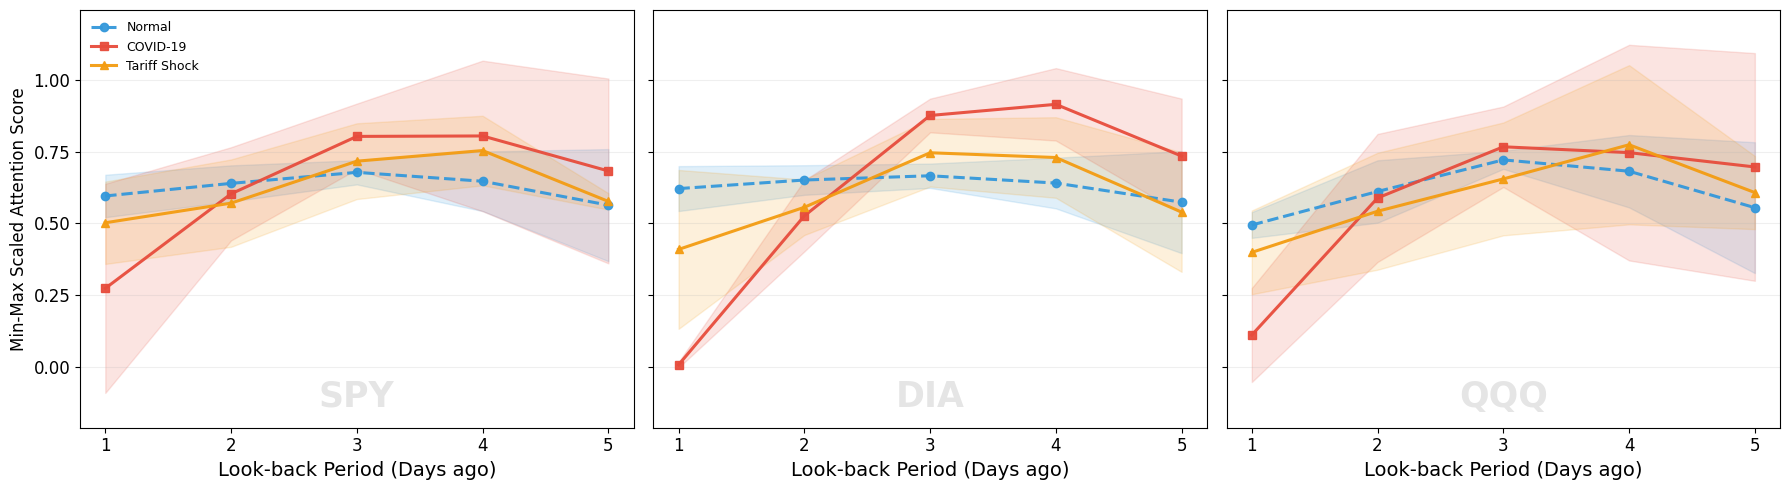

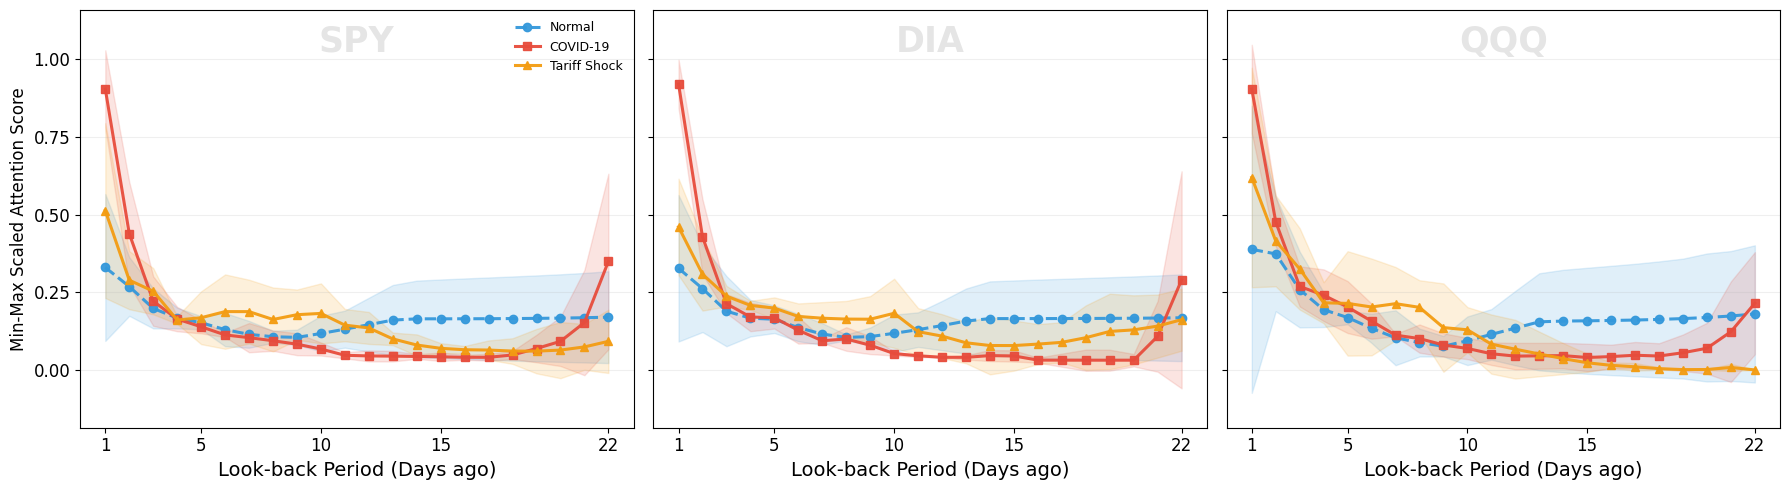

In [5]:
c_norm, c_covid, c_tariff = '#3498db', '#e74c3c', '#f39c12'
REGIMES = ['Normal', 'COVID-19', 'Tariff Shock']
COLORS = {'Normal': c_norm, 'COVID-19': c_covid, 'Tariff Shock': c_tariff}
STYLES = {'Normal': ('--', 'o'), 'COVID-19': ('-', 's'), 'Tariff Shock': ('-', '^')}

def mad_func(x):
    return (x - x.median()).abs().median()

median_by_sym, spread_by_sym = {}, {}
for sym in symbols:
    sub = summary_mm[summary_mm['Symbol'] == sym]
    med = sub.groupby('Regime')[W_COLS + M_COLS].median().reindex(REGIMES)
    spread = sub.groupby('Regime')[W_COLS + M_COLS].agg(mad_func).reindex(REGIMES) * 1.4826
    median_by_sym[sym] = med
    spread_by_sym[sym] = spread

def plot_errorbar_by_symbol(cols, lags, xticks, savepath, watermark_y):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    vals_for_ylim = []
    for sym in symbols:
        for regime in REGIMES:
            median_p = median_by_sym[sym].loc[regime, cols].values
            spread_p = spread_by_sym[sym].loc[regime, cols].values
            vals_for_ylim.append(median_p - spread_p)
            vals_for_ylim.append(median_p + spread_p)
    vals_for_ylim = np.concatenate(vals_for_ylim)
    ylim_lo, ylim_hi = vals_for_ylim.min(), vals_for_ylim.max()
    pad = 0.1 * (ylim_hi - ylim_lo)
    ylim = (ylim_lo - pad, ylim_hi + pad)

    for j, sym in enumerate(symbols):
        ax = axes[j]
        for regime in REGIMES:
            median_p = median_by_sym[sym].loc[regime, cols].values
            spread_p = spread_by_sym[sym].loc[regime, cols].values
            ls, marker = STYLES[regime]
            ax.plot(lags, median_p, label=regime, color=COLORS[regime], linestyle=ls,
                    marker=marker, markersize=6, linewidth=2.2, alpha=0.95, zorder=3)
            ax.fill_between(lags, median_p - spread_p, median_p + spread_p,
                             color=COLORS[regime], alpha=0.15, zorder=1)

        ax.text(0.5, watermark_y, sym, transform=ax.transAxes,
                fontsize=25, fontweight='bold', alpha=0.1, ha='center')
        ax.set_xticks(xticks)
        ax.set_ylim(*ylim)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, axis='y', alpha=0.2)
        ax.set_xlabel("Look-back Period (Days ago)", fontsize=14)
        if j == 0:
            ax.set_ylabel("Min-Max Scaled Attention Score", fontsize=12)
            ax.legend(fontsize=9, frameon=False, loc='best')

    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

# Figure 4 - Mid-term (Week) attention, lags 1-5
plot_errorbar_by_symbol(W_COLS, np.arange(1, 6), np.arange(1, 6), 'result/Figure4.png', watermark_y=0.05)

# Figure 5 - Long-term (Month) attention, lags 1-22
plot_errorbar_by_symbol(M_COLS, np.arange(1, 23), [1, 5, 10, 15, 22], 'result/Figure5.png', watermark_y=0.9)

## Figure 6 - Regime-dependent cross-horizon (mid- vs. long-term) selection weights

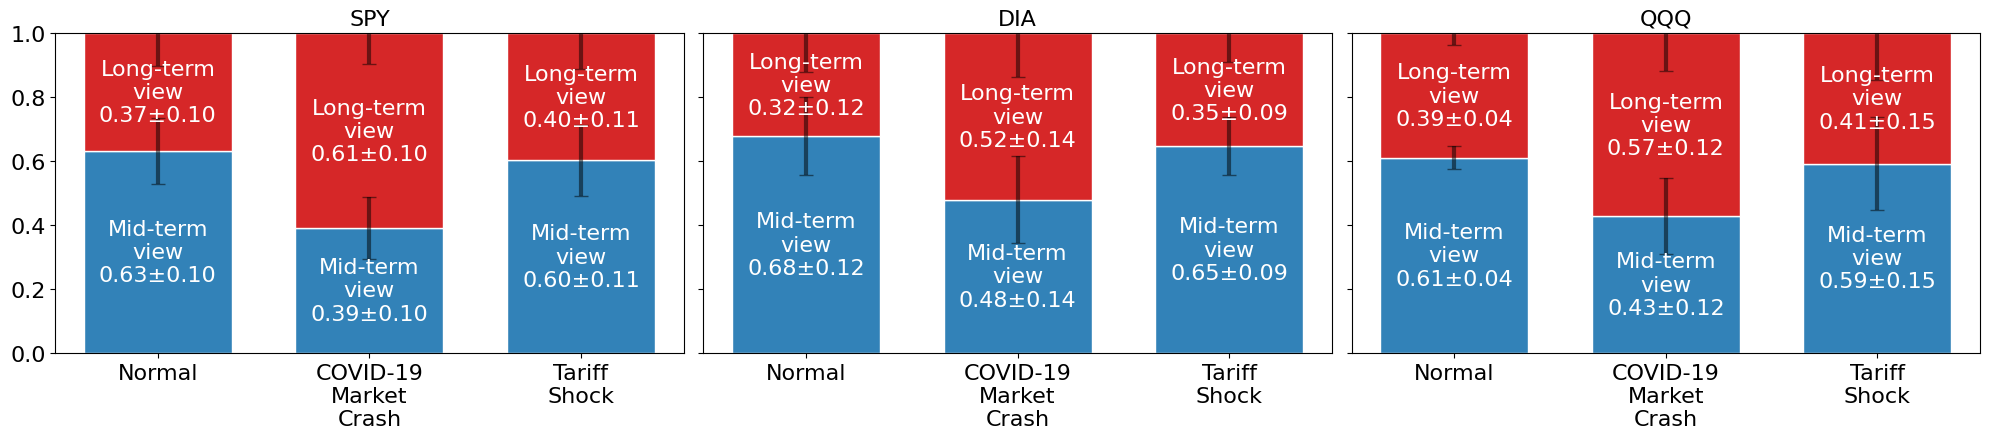

In [6]:
c_mid = '#3282b8'   # Mid-term view
c_long = '#d62728'  # Long-term view
symbols_ordered = ['SPY', 'DIA', 'QQQ']

def robust_center_spread(values):
    """values: 1D array (per-seed values) -> median, 1.4826*MAD"""
    values = np.asarray(values, dtype=float)
    median = np.median(values)
    mad = np.median(np.abs(values - median))
    return median, 1.4826 * mad

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5), sharey=True)

for i, sym in enumerate(symbols_ordered):
    df_raw = data_storage[sym]['df_raw'].copy()
    df_raw['Date'] = pd.to_datetime(df_raw['Date'])
    seeds = sorted(df_raw['seed'].unique())

    def seed_proportions(sub_by_seed_fn):
        mid_props, long_props = [], []
        for seed in seeds:
            sub = sub_by_seed_fn(seed)
            w_e, m_e = sub['Week_Weight'].mean(), sub['Month_Weight'].mean()
            mid_props.append(w_e / (w_e + m_e))
            long_props.append(m_e / (w_e + m_e))
        return mid_props, long_props

    def normal_sub(seed):
        sub = df_raw[df_raw['seed'] == seed]
        mask = pd.Series(True, index=sub.index)
        for start, end in periods.values():
            mask &= ~((sub['Date'] >= start) & (sub['Date'] <= end))
        return sub[mask]

    event_rows = []
    mid_props, long_props = seed_proportions(normal_sub)
    mid_med, mid_spread = robust_center_spread(mid_props)
    long_med, long_spread = robust_center_spread(long_props)
    event_rows.append({'Event': 'Normal', 'Mid_med': mid_med, 'Mid_spread': mid_spread,
                        'Long_med': long_med, 'Long_spread': long_spread})

    for e_name, (start, end) in periods.items():
        mid_props, long_props = seed_proportions(
            lambda seed, start=start, end=end: df_raw[
                (df_raw['seed'] == seed) & (df_raw['Date'] >= start) & (df_raw['Date'] <= end)
            ]
        )
        mid_med, mid_spread = robust_center_spread(mid_props)
        long_med, long_spread = robust_center_spread(long_props)
        event_rows.append({'Event': e_name.replace(" ", "\n"), 'Mid_med': mid_med, 'Mid_spread': mid_spread,
                            'Long_med': long_med, 'Long_spread': long_spread})

    e_df = pd.DataFrame(event_rows)
    ax = axes[i]

    ax.bar(e_df['Event'], e_df['Mid_med'], color=c_mid, edgecolor='white', width=0.7)
    ax.bar(e_df['Event'], e_df['Long_med'], bottom=e_df['Mid_med'], color=c_long, edgecolor='white', width=0.7)

    ax.errorbar(e_df['Event'], e_df['Mid_med'], yerr=e_df['Mid_spread'],
                fmt='none', ecolor='black', elinewidth=3, capsize=5, zorder=5, alpha=0.5)
    top = e_df['Mid_med'] + e_df['Long_med']
    ax.errorbar(e_df['Event'], top, yerr=e_df['Long_spread'],
                fmt='none', ecolor='black', elinewidth=3, capsize=5, zorder=5, alpha=0.5)

    for idx, row in e_df.iterrows():
        ax.text(idx, row['Mid_med'] / 2,
                f"Mid-term\nview\n{row['Mid_med']:.2f}\u00b1{row['Mid_spread']:.2f}",
                ha='center', va='center', color='white', fontsize=16, zorder=10)
        ax.text(idx, row['Mid_med'] + row['Long_med'] / 2,
                f"Long-term\nview\n{row['Long_med']:.2f}\u00b1{row['Long_spread']:.2f}",
                ha='center', va='center', color='white', fontsize=16, zorder=10)

    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylim(0, 1.0)
    ax.set_title(sym, fontsize=16)

plt.tight_layout()
plt.savefig('result/Figure6.png', dpi=300, bbox_inches='tight')
plt.show()